# Deep learning models for arrhythmia detection and diagnosis

## Initialisation

In [1]:
# Imports
from os.path import join as osj
import pandas as pd
import numpy as np
import torch
import wfdb
import pywt
import matplotlib.pyplot as plt
import math
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Directory where the dataset is stored
dataset_directory = 'mit-bih-arrhythmia-database-1.0.0/'

# Initialise dictionaries and arrays to store data
lead1 = {}
lead2 = {}
signal_pairs = {}
annotations = {}

# Information about the labels
beat_annotations = [
    'N',  # Normal beat
    'L',  # Left bundle branch block beat
    'R',  # Right bundle branch block beat
    'B',  # Bundle branch block beat (unspecified)
    'e',  # Atrial escape beat
    'j',  # Nodal (junctional) escape beat

    'A',  # Atrial premature beat
    'a',  # Aberrated atrial premature beat
    'J',  # Nodal (junctional) premature beat
    'S',  # Supraventricular premature or ectopic beat (atrial or nodal)
    
    'V',  # Premature ventricular contraction
    'E',  # Ventricular escape beat
    'r',  # R-on-T premature ventricular contraction

    'F',  # Fusion of ventricular and normal beat
    
    'f',  # Fusion of paced and normal beat
    '/',  # Paced beat
    'Q',  # Unclassifiable beat
    '?',  # Beat not classified 
]

non_beat_annotations = [
    '[',  # Start of ventricular flutter/fibrillation
    '!',  # Ventricular flutter wave
    ']',  # End of ventricular flutter/fibrillation
    'x',  # Non-conducted P-wave (blocked APC)
    '(',  # Waveform onset
    ')',  # Waveform end
    'p',  # Peak of P-wave
    't',  # Peak of T-wave
    'u',  # Peak of U-wave
    '`',  # PQ junction
    "'",  # J-point
    '^',  # Non-captured pacemaker artifact
    '|',  # Isolated QRS-like artifact
    '~',  # Change in signal quality
    '+',  # Rhythm change
    's',  # ST segment change
    'T',  # T-wave change
    '*',  # Systole
    'D',  # Diastole
    '=',  # Measurement annotation
    '"',  # Comment annotation
    '@'   # Link to external data
]

# Label map designed to map MIT-BIH labels into the AAMI classes
AAMI_classes = {
    # N class
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0, 'B': 0,  
    # S class
    'A': 1, 'a': 1, 'J': 1, 'S': 1,                        
    # V class
    'V': 2, 'E': 2, 'r': 2,                                
    # F class
    'F': 3,                      
    # Q Class                          
    'f': 4, '/': 4, 'Q': 4, '?': 4  
}
    
# Create a Dataset object to be used later for training and testing
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32) 
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


## Data Preprocessing

### Preprocessing functions

In [2]:
def swt_denoise(signal_pair):
    """
    Denoises a pair of ECG signals using SWT with soft thresholding.

    Parameters:
        signal_pair (Tuple[np.ndarray, np.ndarray]): Pair of 1D signals.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Denoised pair.
    """
    def _denoise(signal):
        # Decompose
        max_level = pywt.swt_max_level(len(signal))
        wavelet = "bior3.1"
        coeffs = pywt.swt(signal, wavelet, level=max_level)

        
        detail_coeffs = np.array(coeffs[0][1])
        sigma = np.median(np.abs(detail_coeffs)) / 0.6745
        threshold = sigma * np.sqrt(2 * np.log(len(signal)))

        # Threshold coefficients
        new_coeffs = []
        for approx, detail in coeffs:
            detail = pywt.threshold(detail, threshold, mode='soft')
            new_coeffs.append((approx, detail))

        # Reconstruct and return
        return pywt.iswt(new_coeffs, wavelet)
    
    lead1, lead2 = signal_pair[:, 0], signal_pair[:, 1]
    return _denoise(lead1), _denoise(lead2)

def standardise(signal_pair):
    """
    Standardises a pair of ECG signals.

    Parameters:
        signal_pair (Tuple[np.ndarray, np.ndarray]): Pair of 1D signals.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Standardised signals.
    """
    def _standardise(signal):
        mean_val = np.mean(signal)
        std_val = np.std(signal)
        return (signal - mean_val) / std_val

    lead1, lead2 = signal_pair
    return _standardise(lead1), _standardise(lead2)
 
def segmentation_fixed_window(signal_pair, annotation, before=100, after=200):
    """
    Segments beats using a fixed window around each R-peak for both leads.

    Parameters:
        signal_pair (Tuple[np.ndarray, np.ndarray]): Tuple of 1D ECG signals (lead1, lead2).
        annotation (wfdb.Annotation): Annotation object with R-peaks.
        before (int): Number of samples before the R-peak.
        after (int): Number of samples after the R-peak.

    Returns:
        segments (List[np.ndarray]): List of 2x300 segments (2 leads).
        labels (List[str]): Corresponding beat labels.
    """
    lead1, lead2 = signal_pair
    r_peaks = annotation.sample
    r_labels = annotation.symbol

    segments = []
    labels = []

    for peak, label in zip(r_peaks, r_labels):
        start = peak - before
        end = peak + after

        # Ensure segment is within signal bounds
        if start < 0 or end > len(lead1):
            continue

        if label in beat_annotations:
            seg1 = lead1[start:end]
            seg2 = lead2[start:end]
            segment = np.stack([seg1, seg2], axis=0) # Shape: [2, window_length]
            segments.append(segment)
            labels.append(AAMI_classes[label])

    return segments, labels
             
def process_signal(signal_pair, annotation):
    """
    Takes an id and returns the X, y for that id.
    
    Parameters:
        id (int): The id of the record.
        
    Returns:
        tuple: A tuple containing the segments and labels.
    """
    denoised_pair = swt_denoise(signal_pair)
    normalised_pair = standardise(denoised_pair)
    segmented_pair, y = segmentation_fixed_window(normalised_pair, annotation)
        
    X = np.array(segmented_pair)  # Convert to numpy array
    
    X = torch.tensor(X, dtype=torch.float32)  

    y = torch.tensor(y, dtype=torch.long)
    
    return X, y

### Load data, apply processing to data and separate into train and testing

In [3]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from collections import Counter

# Get an array of all ids
record_ids = pd.read_csv('mit-bih-arrhythmia-database-1.0.0/RECORDS', header=None).to_numpy().reshape(-1)

X = []
y = []

# Load the data
for id in record_ids:
    signal, info = wfdb.io.rdsamp(osj(dataset_directory, str(id)))
    annotation = wfdb.rdann(dataset_directory + str(id), "atr")
    X_i, y_i = process_signal(signal, annotation)
    X.append(X_i)
    y.append(y_i)

X = np.concatenate(X, axis=0) 
y = np.concatenate(y, axis=0) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train)


X_train_flat = X_train.reshape(X_train.shape[0], -1)  # Reshape to 2D (num_samples, num_channels * sequence_length)

# Apply SMOTE to the flattened data
smote = SMOTE(sampling_strategy='auto', k_neighbors=5)
X_train_resampled_flat, y_train_resampled = smote.fit_resample(X_train_flat, y_train)

# Reshape back to the original shape if necessary
X_train_resampled = X_train_resampled_flat.reshape(X_train_resampled_flat.shape[0], X_train.shape[1], X_train.shape[2])

# Optional: Print class distributions
print("Original y_train:", Counter(y_train))
print("Resampled y_train:", Counter(y_train_resampled))
print("Validation:", Counter(y_val))
print("Test:", Counter(y_test))

/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original y_train: Counter({0: 54352, 4: 4823, 2: 4341, 1: 1669, 3: 482})
Resampled y_train: Counter({0: 54352, 1: 54352, 4: 54352, 2: 54352, 3: 54352})
Validation: Counter({0: 18118, 4: 1608, 2: 1447, 1: 556, 3: 160})
Test: Counter({0: 18119, 4: 1608, 2: 1447, 1: 556, 3: 160})


## Models

### Beat Classifier

In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_pool = torch.mean(x, dim=-1)
        max_pool, _ = torch.max(x, dim=-1)
        channel_attention = self.sigmoid(self.fc2(self.fc1(avg_pool)) + self.fc2(self.fc1(max_pool)))
        return x * channel_attention.unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv1d(in_channels=2 , out_channels=1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_pool = torch.mean(x, dim=1, keepdim=True)  
        max_pool, _ = torch.max(x, dim=1, keepdim=True)  
        x_att = torch.cat([avg_pool, max_pool], dim=1) 
        x_att = self.sigmoid(self.conv(x_att)) 
        return x * x_att 
    
class CBAMBlock(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, downsample=False):
        super(ResidualBlock1D, self).__init__()
        stride = 2 if downsample else 1
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.cbam = CBAMBlock(out_channels)

        self.downsample = nn.Sequential()
        if downsample or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        identity = self.downsample(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.cbam(x)
        x += identity
        return self.relu(x)
    
class ResNet1D(nn.Module):
    def __init__(self):
        super(ResNet1D, self).__init__()
        self.ResNet = nn.Sequential(
            ResidualBlock1D(2, 32, downsample=True),  
            ResidualBlock1D(32, 64, downsample=True), 
            ResidualBlock1D(64, 128, downsample=True)
        )
        self.pool = nn.AdaptiveAvgPool1d(32)


    def forward(self, x):
        x = self.ResNet(x)
        return self.pool(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return x

class Classifier(nn.Module):
    def __init__(self, input_dim=128, num_classes=5):
        super(Classifier, self).__init__()
        
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)
    
class TransformerEncoder(nn.Module):
    def __init__(self, *args, **kwargs):
        super(TransformerEncoder, self).__init__(*args, **kwargs)

    
class RATNet(nn.Module):
    def __init__(self, num_classes=5):
        super(RATNet, self).__init__()
        self.ResNet = ResNet1D()
        self.channel_attention = ChannelAttention(128)
        self.spatial_attention = SpatialAttention()
        self.position_encoder = PositionalEncoding(128) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.flatten = nn.Flatten()
        self.classifier = Classifier(input_dim=128, num_classes=num_classes)

    def forward(self, x):
        x = self.ResNet(x)             
        x = x.permute(2,0,1)
        x = self.position_encoder(x)
        x = self.transformer(x)        
        x = x.mean(dim=0)       
        x = self.classifier(x)           
        return x

## Training

### Training Parameters

In [5]:


if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    pass
    
device = torch.device("cpu")


print(device)

epochs = 30
batch_size = 128
learning_rate = 0.001
weight_decay = 1e-5

train_dataset = ECGDataset(X_train_resampled, y_train_resampled)
test_dataset = ECGDataset(X_test, y_test)
validation_dataset = ECGDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

# Compute class weights
counts = np.bincount(y_train)
weights = 1.0 / counts
weights = weights * (len(counts)) 
weights = weights / weights.sum() * len(counts) 

class_weights = torch.from_numpy(weights).float().to(device)

criterion = nn.CrossEntropyLoss()

model = RATNet().to(device)
optimiser = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=3)

cpu


/Users/elijah/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


### Training loop

In [6]:
for epoch in range(epochs):
    # Training phase
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device) 
        labels = labels.to(device)

        optimiser.zero_grad()
        outputs = model(inputs)

        # probs = torch.softmax(outputs, dim=1)
        # print("Predictions (first 5):", torch.argmax(probs, dim=1)[:40].cpu().numpy())

        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / total
    train_acc = correct / total
    
    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss, val_correct, val_total = 0, 0, 0
    
    with torch.no_grad():  # No gradients are computed during validation
        for inputs, labels in validation_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - "
            f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - "
            f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")


Epoch 1/30 - Train Loss: 0.1888 - Train Acc: 0.9359 - Val Loss: 0.1551 - Val Acc: 0.9529
Epoch 2/30 - Train Loss: 0.0758 - Train Acc: 0.9758 - Val Loss: 0.1026 - Val Acc: 0.9706
Epoch 3/30 - Train Loss: 0.0568 - Train Acc: 0.9817 - Val Loss: 0.2395 - Val Acc: 0.9238
Epoch 4/30 - Train Loss: 0.0478 - Train Acc: 0.9848 - Val Loss: 0.0718 - Val Acc: 0.9779


KeyboardInterrupt: 

## Testing

Test Accuracy:     98.1316
Test Precision:    86.3845
Test Recall:       94.7340
Test F1 Score:     89.9776
Confusion Matrix (Test):


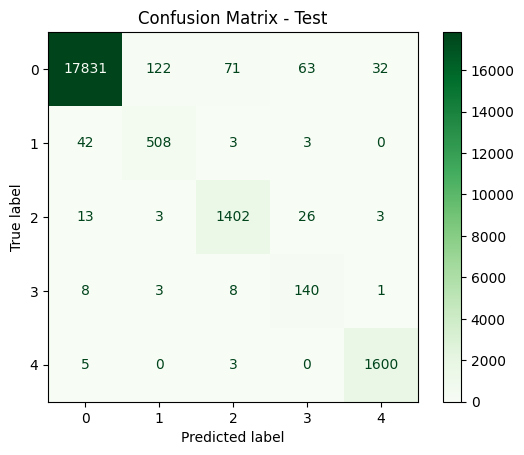

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)


print(f"Test Accuracy:     {acc*100:.4f}") # average=None? 
print(f"Test Precision:    {precision*100:.4f}")
print(f"Test Recall:       {recall*100:.4f}")
print(f"Test F1 Score:     {f1*100:.4f}")

print("Confusion Matrix (Test):")
cm_test = confusion_matrix(all_labels, all_preds)
cm_test_disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1, 2, 3, 4])
cm_test_disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Test")
plt.show()